In [ ]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch import nn
import numpy as np

In [ ]:
data = pd.read_csv("/content/Fish.csv")
data.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [ ]:
data.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [ ]:
data.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

In [ ]:
X = data.iloc[:, 2: ]
X

,Length1,Length2,Length3,Height,Width
0,23.2,25.4,30.0,11.5200,4.0200
1,24.0,26.3,31.2,12.4800,4.3056
2,23.9,26.5,31.1,12.3778,4.6961
3,26.3,29.0,33.5,12.7300,4.4555
4,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...
154,11.5,12.2,13.4,2.0904,1.3936
155,11.7,12.4,13.5,2.4300,1.2690
156,12.1,13.0,13.8,2.2770,1.2558
157,13.2,14.3,15.2,2.8728,2.0672


In [ ]:
y = data['Weight']
y

,Weight
0,242.0
1,290.0
2,340.0
3,363.0
4,430.0
...,...
154,12.2
155,13.4
156,12.2
157,19.7


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((127, 5), (32, 5), (127,), (32,))

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
scaler.fit(X_train)

StandardScaler()

In [ ]:
X_train_scaled = scaler.transform(X_train)

In [ ]:
X_train_scaled.shape

(127, 5)

In [ ]:
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_test_scaled.shape

(32, 5)

In [ ]:
y_train.shape , y_test.shape

((127,), (32,))

In [ ]:
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.fit_transform(y_test.values.reshape(-1,1))

In [ ]:
y_train_scaled.shape , y_test_scaled.shape

((127, 1), (32, 1))

In [ ]:
X_train_scaled.shape , y_train_scaled.shape , X_test_scaled.shape , y_test_scaled.shape

((127, 5), (127, 1), (32, 5), (32, 1))

In [ ]:
import torch
device = torch.device("cpu")
if torch.cuda.is_available():
  device = torch.device("cuda")
elif torch.backends.mps.is_available():
  device = torch.device("mps")
print("Using device :" , device)

Using device : cpu


In [ ]:
X_train_scaled = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_scaled = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_scaled = torch.tensor(y_test_scaled, dtype=torch.float32)

In [ ]:
X_train_scaled.dtype , X_test_scaled.dtype , y_train_scaled.dtype , y_test_scaled.dtype

(torch.float32, torch.float32, torch.float32, torch.float32)

In [ ]:
X_train_scaled.shape , X_test_scaled.shape , y_train_scaled.shape , y_test_scaled.shape

(torch.Size([127, 5]),
 torch.Size([32, 5]),
 torch.Size([127, 1]),
 torch.Size([32, 1]))

In [ ]:
from torch import nn
import torch
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(in_features = 5, out_features = 1)
  def forward(self, x):
    return self.linear(x)


In [ ]:
model = LinearRegressionModel()
print(model.linear.weight.shape)
print(model.linear.bias.shape)
print(model.linear.weight)
print(model.linear.bias)

torch.Size([1, 5])
torch.Size([1])
Parameter containing:
tensor([[-0.1004, -0.1753,  0.0971,  0.3562,  0.1108]], requires_grad=True)
Parameter containing:
tensor([0.1547], requires_grad=True)


In [ ]:
from torch import nn
model = LinearRegressionModel()
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001, momentum =0.9)

In [ ]:
model.eval()
with torch.no_grad():

  X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)
  y_pred = model(X_test_scaled)
  print(y_pred)

tensor([[-0.4119],
        [-0.5777],
        [-0.7227],
        [-0.3380],
        [-0.4612],
        [ 0.0720],
        [-0.5721],
        [-0.4136],
        [-0.3821],
        [-0.7150],
        [-0.1183],
        [-0.2865],
        [-0.0585],
        [-0.2809],
        [-0.1025],
        [-0.0392],
        [-0.1768],
        [-0.4256],
        [-0.3993],
        [-0.1424],
        [-0.5683],
        [-0.1468],
        [-0.2585],
        [-0.1455],
        [-0.0398],
        [-0.2585],
        [-0.4234],
        [-0.3597],
        [-0.5621],
        [-0.5826],
        [-0.8169],
        [-0.4208]])


/tmp/ipykernel_347/980359181.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)


In [ ]:
model = model.to(torch.float32)

In [ ]:
for i in range(0,100000):
  optimizer.zero_grad()
  outputs = model(X_train_scaled)
  loss = loss_fn(outputs, y_train_scaled)
  loss.backward()
  optimizer.step()
  if i%10==0:
    print(f'Epoch[{i+1}/100000] , Loss : {loss.item()}')

Streaming output truncated to the last 5000 lines.
Epoch[50001/100000] , Loss : 0.1162419468164444
Epoch[50011/100000] , Loss : 0.11624187231063843
Epoch[50021/100000] , Loss : 0.11624181270599365
Epoch[50031/100000] , Loss : 0.1162417083978653
Epoch[50041/100000] , Loss : 0.11624164134263992
Epoch[50051/100000] , Loss : 0.11624157428741455
Epoch[50061/100000] , Loss : 0.11624147742986679
Epoch[50071/100000] , Loss : 0.11624140292406082
Epoch[50081/100000] , Loss : 0.11624132841825485
Epoch[50091/100000] , Loss : 0.11624123156070709
Epoch[50101/100000] , Loss : 0.11624116450548172
Epoch[50111/100000] , Loss : 0.11624108999967575
Epoch[50121/100000] , Loss : 0.11624100804328918
Epoch[50131/100000] , Loss : 0.11624093353748322
Epoch[50141/100000] , Loss : 0.11624084413051605
Epoch[50151/100000] , Loss : 0.11624076217412949
Epoch[50161/100000] , Loss : 0.11624069511890411
Epoch[50171/100000] , Loss : 0.11624062061309814
Epoch[50181/100000] , Loss : 0.11624054610729218
Epoch[50191/100000] 

In [ ]:
model.eval()
with torch.no_grad():
  y_pred = model(X_test_scaled)
  print(y_pred)

tensor([[-0.8734],
        [-1.5627],
        [-0.0025],
        [-0.2391],
        [-0.5851],
        [ 1.1149],
        [-1.7216],
        [-0.3246],
        [-0.3346],
        [ 2.0859],
        [ 0.6325],
        [ 1.1345],
        [ 0.5629],
        [-0.6155],
        [ 0.7620],
        [ 1.1422],
        [ 1.5422],
        [-0.1094],
        [-0.3697],
        [ 0.5687],
        [-1.6130],
        [ 0.6579],
        [ 0.3653],
        [ 0.3611],
        [ 1.1512],
        [ 1.4849],
        [-0.4722],
        [-0.2247],
        [-1.7875],
        [-1.6222],
        [ 0.8551],
        [-1.0302]])


In [ ]:
y_test_scaled

tensor([[-0.9707],
        [-1.1420],
        [-0.6472],
        [-0.4616],
        [-0.7798],
        [ 1.4740],
        [-1.1590],
        [-0.7002],
        [-0.6790],
        [ 2.1369],
        [ 0.5460],
        [ 1.4740],
        [ 0.4134],
        [-0.7798],
        [ 0.6785],
        [ 1.2619],
        [ 1.4740],
        [-0.5995],
        [-0.5809],
        [ 0.6785],
        [-1.1510],
        [ 0.4399],
        [ 0.1482],
        [ 0.1482],
        [ 1.3547],
        [ 1.7391],
        [-0.7268],
        [-0.4616],
        [-1.1597],
        [-1.1513],
        [ 0.1747],
        [-0.9919]])

In [ ]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
mean_absolute_error(y_test_scaled, y_pred)
mean_squared_error(y_test_scaled, y_pred)
r2 = r2_score(y_test_scaled, y_pred)
print(f"R-squarred : {r2:.3f}")
mse = mean_squared_error(y_test_scaled, y_pred)
print(f"MSE : {mse:.3f}")
print(f"MAE : {mean_absolute_error(y_test_scaled , y_pred):.3f}")

R-squarred : 0.889
MSE : 0.111
MAE : 0.280


In [ ]:
y_test_scaled.shape , y_pred.shape

(torch.Size([32, 1]), torch.Size([32, 1]))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

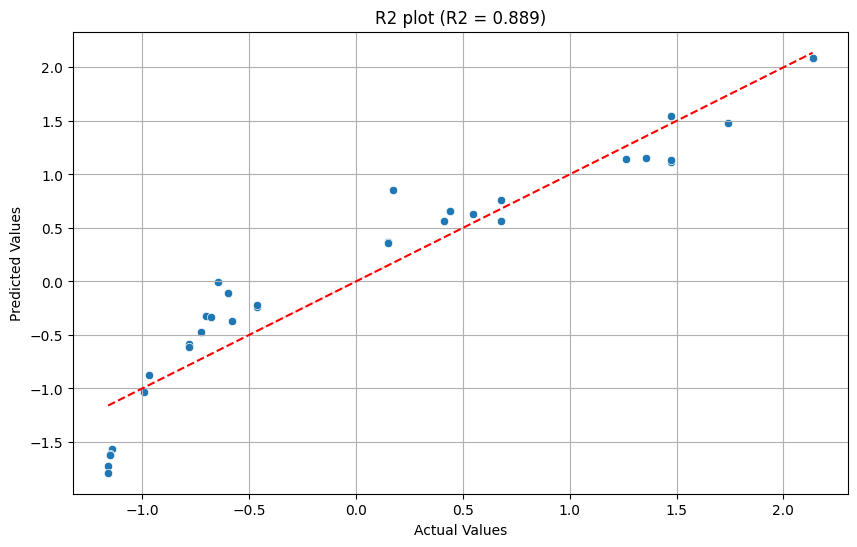

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_scaled.ravel(), y=y_pred.ravel())
sns.lineplot(x=y_test_scaled.ravel(), y=y_test_scaled.ravel(), color='red',linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f"R2 plot (R2 = {r2:.3f})")
plt.grid(True)
plt.show()

In [ ]:
y_pred_original = scaler_y.inverse_transform(y_pred.detach().numpy())


In [ ]:
y_test.shape , y_pred_original.shape

((32,), (32, 1))

In [ ]:
y_pred_original

array([[ 114.68887 ],
       [-145.2887  ],
       [ 443.15872 ],
       [ 353.91882 ],
       [ 223.4351  ],
       [ 864.572   ],
       [-205.20367 ],
       [ 321.6565  ],
       [ 317.90674 ],
       [1230.7736  ],
       [ 682.6222  ],
       [ 871.9755  ],
       [ 656.40125 ],
       [ 211.96706 ],
       [ 731.489   ],
       [ 874.85803 ],
       [1025.7458  ],
       [ 402.8502  ],
       [ 304.64664 ],
       [ 658.59436 ],
       [-164.23212 ],
       [ 692.2291  ],
       [ 581.84766 ],
       [ 580.2705  ],
       [ 878.27966 ],
       [1004.1013  ],
       [ 265.99692 ],
       [ 359.3442  ],
       [-230.04718 ],
       [-167.70062 ],
       [ 766.59393 ],
       [  55.555634]], dtype=float32)

In [ ]:
y_test

,Weight
78,78.0
155,13.4
128,200.0
55,270.0
94,150.0
29,1000.0
147,7.0
51,180.0
98,188.0
141,1250.0
